In [1]:
#importing all the packages required in the work we do
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
print (tf.__version__)

2.4.1


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
os.chdir('/content')

In [5]:
!pip install PyDrive

In [6]:
# Packages to import data files into the google colab
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

In [7]:
# 1. Authenticate and create the PyDrive client.
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

In [8]:
# Get the data file
downloaded = drive.CreateFile({'id':"1saZ-xa27Sr8iWOjh9qy5HPwgu1GHRki8"})   # replace the id with id of file you want to access
downloaded.GetContentFile('Part 1- Train data - images.npy')

In [9]:
#Get the weights of model file
downloaded = drive.CreateFile({'id':"1rx5gAZvHqGkGsfzWz2D5cOijKFrrXzP4"})   # replace the id with id of file you want to access
downloaded.GetContentFile('Part 3 - vgg_face_weights.h5')

In [10]:
# Load the dataset in the data variable
data = np.load('/content/Part 1- Train data - images.npy',allow_pickle=True)

In [11]:
print (data[20][1])

[{'label': ['Face'], 'notes': '', 'points': [{'x': 0.4979166666666667, 'y': 0.20833333333333334}, {'x': 0.7854166666666667, 'y': 0.6888888888888889}], 'imageWidth': 480, 'imageHeight': 360}]


In [12]:
#Setting image width and height
IMAGE_HEIGHT=224
IMAGE_WIDTH=224

HEIGHT_CELLS = 28
WIDTH_CELLS = 28

In [13]:
import cv2
from tensorflow.keras.applications.mobilenet import preprocess_input

#Setting up masks
masks = np.zeros((int(data.shape[0]), IMAGE_HEIGHT, IMAGE_WIDTH))
X = np.zeros((int(data.shape[0]), IMAGE_HEIGHT, IMAGE_WIDTH, 3))
for index in range(data.shape[0]):
    img = data[index][0]
    img = cv2.resize(img, dsize=(IMAGE_HEIGHT, IMAGE_WIDTH), interpolation=cv2.INTER_CUBIC)
    # Preventing any errors to stop the program, we use exception hadling
    try:
      img = img[:, :, :3]
    except:
      continue
    X[index] = preprocess_input(np.array(img, dtype=np.float32))
    for i in data[index][1]:
        x1 = int(i["points"][0]['x'] * IMAGE_WIDTH)
        x2 = int(i["points"][1]['x'] * IMAGE_WIDTH)
        y1 = int(i["points"][0]['y'] * IMAGE_HEIGHT)
        y2 = int(i["points"][1]['y'] * IMAGE_HEIGHT)
        masks[index][y1:y2, x1:x2] = 1

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


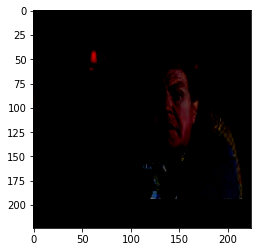

In [14]:
plt.imshow(X[20])

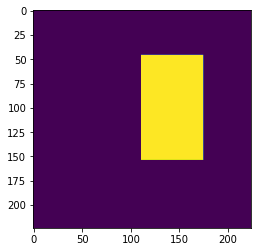

In [15]:
# squeeze to remove single-dimensional entries
plt.imshow(masks[20].squeeze())

In [16]:
print(X.shape)
print(masks.shape)

(409, 224, 224, 3)
(409, 224, 224)


In [17]:
#Taking 1st 400 inputs as Training Data
X_train = X[:400,:,:]
y_train = masks[:400,:,:]

In [18]:
#Taking last 9 inputs as Testing Data
X_test = X[400:,:,:]
y_test = masks[400:,:,:]

In [19]:
#Splitting Training dataset for Training & Validation
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

[[[-1.         -1.         -1.        ]
  [-1.         -1.         -1.        ]
  [-1.         -1.         -1.        ]
  ...
  [-1.         -1.         -1.        ]
  [-1.         -1.         -1.        ]
  [-1.         -1.         -1.        ]]

 [[-1.         -1.         -1.        ]
  [-1.         -1.         -1.        ]
  [-1.         -1.         -1.        ]
  ...
  [-1.         -1.         -1.        ]
  [-1.         -1.         -1.        ]
  [-1.         -1.         -1.        ]]

 [[-1.         -1.         -1.        ]
  [-1.         -1.         -1.        ]
  [-1.         -1.         -1.        ]
  ...
  [-1.         -1.         -1.        ]
  [-1.         -1.         -1.        ]
  [-1.         -1.         -1.        ]]

 ...

 [[-0.34901959 -0.75686276 -0.83529413]
  [-0.35686272 -0.7647059  -0.84313726]
  [-0.36470586 -0.74901962 -0.8509804 ]
  ...
  [-0.81960785 -0.88235295 -0.96078432]
  [-0.11372548 -0.08235294 -0.16862744]
  [-0.01960784 -0.06666666 -0.12941176]]

 [

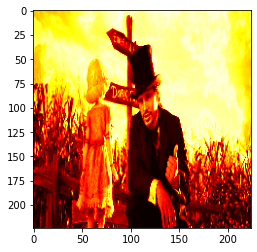

In [20]:
plt.imshow(X_train[10, ..., 0], cmap='hot')
print(X_train[20])

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


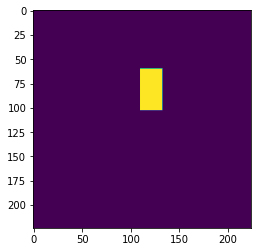

In [21]:
print(y_train[20])
plt.imshow(y_train[20].squeeze())

In [22]:
print(X_train.shape)
print(y_train.shape)

(340, 224, 224, 3)
(340, 224, 224)


In [23]:
print(X_valid.shape)
print(y_valid.shape)

(60, 224, 224, 3)
(60, 224, 224)


In [24]:
from tensorflow.keras.applications.mobilenet import MobileNet
from tensorflow.keras.layers import Reshape, UpSampling2D, Concatenate, Conv2D, Input
from tensorflow.keras.models import Model

# Creating the model which we need to train ahead
def create_model(trainable=True):
    base_model = MobileNet(input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3), include_top=False, alpha=1.0, weights="imagenet")

    for layer in base_model.layers:
        layer.trainable = trainable

# Using pretrained weights from the model
    block0 = base_model.get_layer("conv_pw_1_relu").output 
    block = base_model.get_layer("conv_pw_1_relu").output
    block1 = base_model.get_layer("conv_pw_3_relu").output
    block2 = base_model.get_layer("conv_pw_5_relu").output
    block3 = base_model.get_layer("conv_pw_11_relu").output
    block4 = base_model.get_layer("conv_pw_13_relu").output

    x = Concatenate()([UpSampling2D()(block4), block3])
    x = Concatenate()([UpSampling2D()(x), block2])
    x = Concatenate()([UpSampling2D()(x), block1])
    x = Concatenate()([UpSampling2D()(x), block])
    x = UpSampling2D()(x)
    x = Conv2D(1, kernel_size=1, activation="sigmoid")(x)
    x = Reshape((IMAGE_HEIGHT, IMAGE_WIDTH))(x)

    return Model(inputs=base_model.input, outputs=x)

In [25]:
model = create_model(False)

17227776/17225924 [==============================] - 0s 0us/step


In [26]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
conv1 (Conv2D)                  (None, 112, 112, 32) 864         input_1[0][0]                    
__________________________________________________________________________________________________
conv1_bn (BatchNormalization)   (None, 112, 112, 32) 128         conv1[0][0]                      
__________________________________________________________________________________________________
conv1_relu (ReLU)               (None, 112, 112, 32) 0           conv1_bn[0][0]                   
______________________________________________________________________________________________

In [27]:
# Finding similarities between original and predicted data
def dice_coefficient(y_true, y_pred):
    numerator = 2 * tf.reduce_sum(y_true * y_pred)
    denominator = tf.reduce_sum(y_true + y_pred)

    return numerator / (denominator + tf.keras.backend.epsilon())

In [28]:
# Calculating loss from actual and predicted values
def loss(y_true, y_pred):
    return binary_crossentropy(y_true, y_pred) - tf.math.log(dice_coefficient(y_true, y_pred) + tf.keras.backend.epsilon())

In [29]:
import tensorflow as tf
from keras.optimizers import Adam
from tensorflow.keras.losses import binary_crossentropy
# compile model
model.compile(optimizer='Adam', loss=loss, metrics=[dice_coefficient])

In [30]:
# Getting the pretrained weights of the model used
checkpoint = tf.keras.callbacks.ModelCheckpoint('/content/Part 3 - vgg_face_weights.h5', 
                                                monitor='dice_coefficient', 
                                                save_best_only=True,
                                                save_weights_only=True, 
                                                mode='auto', 
                                                save_freq=1)
stop = tf.keras.callbacks.EarlyStopping(monitor='dice_coefficient', patience=10, mode='auto')
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='dice_coefficient', factor=0.2, patience=5, min_lr=1e-6, verbose=1, mode='auto')

In [31]:
#Training the model with the mentioned hyperparameters
history = model.fit(X_train,y_train,
                    batch_size=1,
                    epochs=10,
                    callbacks=[checkpoint, reduce_lr, stop],
                    validation_data=(X_valid, y_valid),
                    shuffle=True,
                    verbose=1)

Epoch 1/10
340/340 [==============================] - 46s 34ms/step - loss: 1.5754 - dice_coefficient: 0.3979 - val_loss: 0.8760 - val_dice_coefficient: 0.5476
Epoch 2/10
340/340 [==============================] - 11s 31ms/step - loss: 0.8837 - dice_coefficient: 0.5748 - val_loss: 0.8506 - val_dice_coefficient: 0.5647
Epoch 3/10
340/340 [==============================] - 11s 31ms/step - loss: 0.7929 - dice_coefficient: 0.6022 - val_loss: 0.8658 - val_dice_coefficient: 0.5607
Epoch 4/10
340/340 [==============================] - 11s 31ms/step - loss: 0.7272 - dice_coefficient: 0.6345 - val_loss: 0.8439 - val_dice_coefficient: 0.5672
Epoch 5/10
340/340 [==============================] - 11s 32ms/step - loss: 0.8184 - dice_coefficient: 0.6085 - val_loss: 0.8482 - val_dice_coefficient: 0.5715
Epoch 6/10
340/340 [==============================] - 11s 32ms/step - loss: 0.8523 - dice_coefficient: 0.6133 - val_loss: 0.8373 - val_dice_coefficient: 0.5742

Epoch 00006: ReduceLROnPlateau reducing

In [32]:
model.evaluate(X_valid, y_valid, batch_size=1, verbose=1)

60/60 [==============================] - 1s 19ms/step - loss: 0.8302 - dice_coefficient: 0.5725


[0.8301683068275452, 0.5724592208862305]

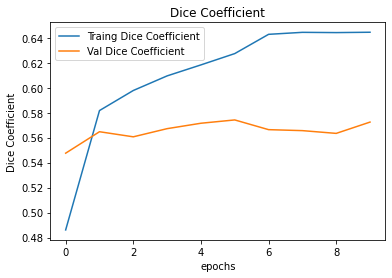

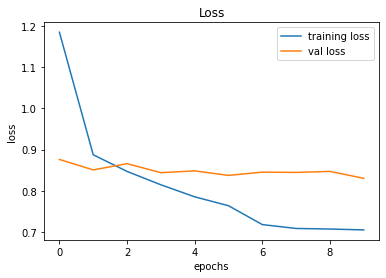

In [33]:
plt.figure(0)
plt.plot(history.history['dice_coefficient'], label='Traing Dice Coefficient')
plt.plot(history.history['val_dice_coefficient'], label='Val Dice Coefficient')
plt.title('Dice Coefficient')
plt.xlabel('epochs')
plt.ylabel('Dice Coefficient')
plt.legend()

plt.figure(1)
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()

In [34]:
def plot_sample(X, y, ix=None):
    if ix is None:
        ix = np.random.randint(0, len(X))

    has_mask = y[ix].max() > 0

    fig, ax = plt.subplots(1, 3, figsize=(20, 10))
    ax[0].imshow(X[ix, ..., 0], cmap='hot')
    if has_mask:
        ax[0].contour(y[ix].squeeze())
    ax[0].set_title('Image')

    ax[1].imshow(y[ix].squeeze())
    ax[1].set_title('Actual Mask')

    preds = model.predict(X,batch_size=1,verbose=1)
    ax[2].imshow(preds[ix].squeeze())
    if has_mask:
        ax[2].contour(preds[ix].squeeze(), colors='k', levels=[0.5])
    ax[2].set_title('Predicted Mask')
    

9/9 [==============================] - 1s 24ms/step


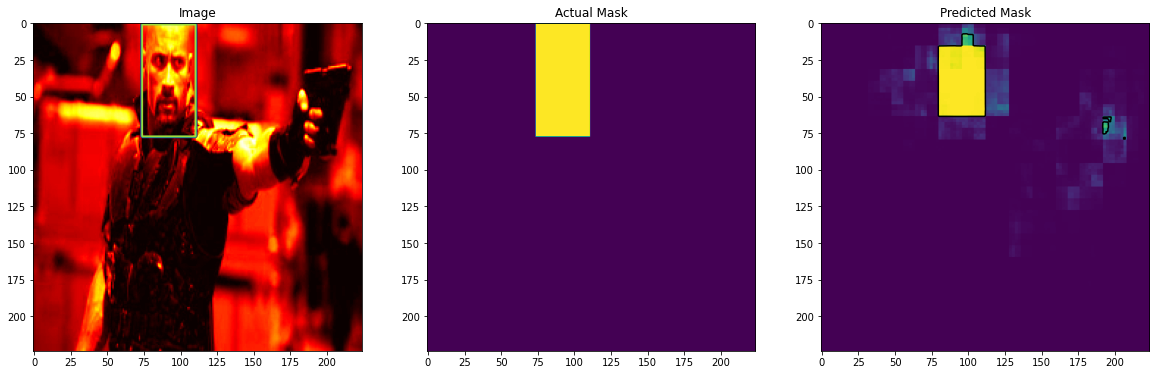

In [35]:
# Printing Test Image, Original Mask & Predicted Mask associated with the Test Image
plot_sample(X_test, y_test)